# Introduction to Clifford Noise Reduction (CliNR)

Clifford Noise Reduction (CliNR) is a method for running a Clifford circuit more accurately on a noisy quantum computer, without the full cost of quantum error correction [1, 2]. This notebook implements the protocol introduced in [1] and demonstrated on hardware in [2]. The central idea is to prepare the Clifford operation on a separate set of qubits, check that the preparation is free of detectable faults, and only then move the operation onto the data. Because faults are caught before they reach the data, they cannot spread into the computation.

This notebook builds that idea up from its foundations. We start with quantum state teleportation, extend it to gate teleportation, and then show that CliNR is gate teleportation with one extra ingredient: verification of the resource state. We close with a test of the protocol on a three-qubit circuit.

### What you will learn

1. How state teleportation moves a quantum state using a Bell pair, a measurement, and a correction.
2. How gate teleportation applies a Clifford operation by building it into the resource state.
3. Why CliNR is gate teleportation plus stabilizer verification, and why that placement of the check is what suppresses errors.
4. How the protocol behaves on a simple three-qubit Clifford circuit, and why CliNR does not reduce errors at this scale.

## Setup

In [1]:
# If these are not already available in your environment:
# %pip install stim numpy matplotlib

import stim
import numpy as np
import matplotlib.pyplot as plt

## 1. State teleportation

State teleportation transfers an unknown single-qubit state from one qubit to another using a shared Bell pair and two bits of classical communication.

We use three qubits:

- qubit 0 holds the state to be teleported, $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$,
- qubits 1 and 2 hold a Bell pair, $|B_{00}\rangle = \tfrac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$.

The initial joint state is $|\psi\rangle_0 \otimes |B_{00}\rangle_{1,2}$, with the subscripts naming the qubits each factor lives on.

To see how teleportation works, we regroup this *same* state around the pair we are about to measure, qubits 0 and 1, expanding them in the Bell basis. Writing $|B_{ab}\rangle_{0,1}$ for the Bell states of qubits 0 and 1:

$$
\begin{aligned}
|\psi\rangle_0 \, |B_{00}\rangle_{1,2} = \tfrac{1}{2}\Big(
  & |B_{00}\rangle_{0,1}\, (\alpha|0\rangle + \beta|1\rangle)_2
  + |B_{01}\rangle_{0,1}\, (\alpha|1\rangle + \beta|0\rangle)_2 \\
  &+ |B_{10}\rangle_{0,1}\, (\alpha|0\rangle - \beta|1\rangle)_2
  + |B_{11}\rangle_{0,1}\, (\alpha|1\rangle - \beta|0\rangle)_2
\Big).
\end{aligned}
$$

Nothing about the state has changed, only the grouping: $|B_{00}\rangle_{1,2}$ on the left describes qubits 1 and 2, while each $|B_{ab}\rangle_{0,1}$ on the right describes qubits 0 and 1 — the pair the protocol measures.

Measuring qubits 0 and 1 in the Bell basis therefore collapses qubit 2 into one of four states, each a known Pauli applied to $|\psi\rangle$. Labeling the two measurement outcomes $a$ (from qubit 0) and $b$ (from qubit 1), qubit 2 holds $Z^{a} X^{b} |\psi\rangle$. Applying the correction $X^{b}$ followed by $Z^{a}$ recovers $|\psi\rangle$ exactly.

In the circuit, the Bell-basis measurement is implemented with a CNOT followed by a Hadamard, after which qubits 0 and 1 are measured in the computational basis.

In [2]:
def build_state_teleportation():
    """
    State teleportation of qubit 0 onto qubit 2 using a Bell pair on qubits 1 and 2.
    The correction on qubit 2 is applied in-circuit via classical feedforward.
    """
    c = stim.Circuit()

    # Prepare a nontrivial state on qubit 0 to teleport (H then S, for illustration).
    c.append("H", [0])
    c.append("S", [0])

    # Create the Bell pair |B_00> on qubits 1 and 2.
    c.append("H", [1])
    c.append("CX", [1, 2])

    # Bell-basis measurement of qubits 0 and 1: CNOT then Hadamard, then measure.
    c.append("CX", [0, 1])
    c.append("H", [0])
    c.append("M", [0])          # outcome a  -> recorded as rec[-2] after next line
    c.append("M", [1])          # outcome b  -> recorded as rec[-1]

    # Feedforward correction on qubit 2: X^b then Z^a.
    c.append("CX", [stim.target_rec(-1), 2])   # X conditioned on b (qubit 1 outcome)
    c.append("CZ", [stim.target_rec(-2), 2])   # Z conditioned on a (qubit 0 outcome)

    return c

state_teleport = build_state_teleportation()

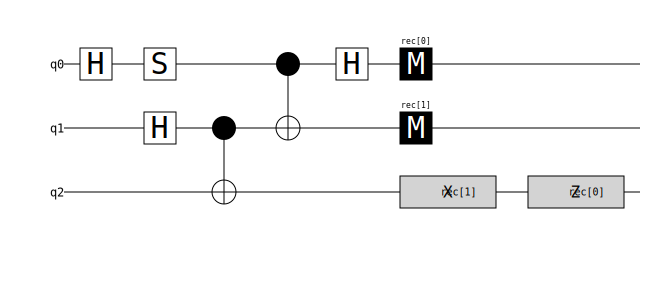

In [3]:
# Render the circuit as an SVG diagram 
state_teleport.diagram("timeline-svg")

### Verifying it works

To confirm teleportation succeeded, we check the protocol against its definition: whatever single-qubit state we prepare on qubit 0 should appear on qubit 2 after the correction. A direct way to test this is to verify that the same preparation, applied to qubit 0, and then "undone" on qubit 2, returns qubit 2 to $|0\rangle$ on every shot.

We build a small test circuit: prepare the state, teleport it, then apply the inverse preparation to qubit 2 and measure. A correct protocol yields outcome 0 on qubit 2 in every shot.

In [4]:
def test_state_teleportation(shots=2000, seed=0):
    """
    Teleport H S |0> from qubit 0 to qubit 2, then apply (H S)^dagger = S^dag H
    to qubit 2 and measure it. A correct protocol gives outcome 0 every time.
    """
    # Build the teleportation circuit
    c = build_state_teleportation() 

    # Undo the preparation on qubit 2: inverse of (H then S) is (S_DAG then H).
    c.append("S_DAG", [2])
    c.append("H", [2])

    # final measurement of qubit 2 to check if it is back to |0>
    c.append("M", [2]) 
                         
    samples = c.compile_sampler(seed=seed).sample(shots)
    qubit2_outcomes = samples[:, -1]        
    return int(qubit2_outcomes.sum())

nonzero = test_state_teleportation()
print(f"Shots where qubit 2 was not |0> after teleport-and-undo: {nonzero}")
assert nonzero == 0, "State teleportation failed: qubit 2 was not restored to |0>."
print("State teleportation verified: the input state was recovered on qubit 2.")

Shots where qubit 2 was not |0> after teleport-and-undo: 0
State teleportation verified: the input state was recovered on qubit 2.


## 2. Gate teleportation

Instead of teleporting a state unchanged, we build a Clifford operation $C$ into the resource state ahead of time. Teleportation then delivers $C|\psi\rangle$ rather than $|\psi\rangle$.

In the example below, we illustrate with a two-qubit Clifford $C$ acting on the teleported register.

### Why it works

Start from the same Bell pair, but apply $C$ to the second half of it. The resource state becomes $(I \otimes C)|B_{00}\rangle$. Running the teleportation protocol with this resource teleports $|\psi\rangle$ through $C$: the output qubits hold $C|\psi\rangle$, again up to a Pauli byproduct set by the measurement outcomes.

Concretely, the circuit uses six qubits: two **data** qubits (0 and 1) holding $|\psi\rangle$, and two sets of **resource** qubits, `res_a` (2 and 3) and `res_b` (4 and 5). We prepare $|\psi\rangle$ on the data qubits, a Bell pair on each of $(q2, q4)$ and $(q3, q5)$, then apply $C$ to the `res_b` half (qubits 4 and 5).We follow with a Bell-basis measurement of each data qubit with its `res_a` partner — $(q0, q2)$ and $(q1, q3)$.

In plain state teleportation the output carries the byproduct $Z^{a}X^{b}$ (Section 1). Gate teleportation runs that protocol with $C$ built into the resource, so the output register (`res_b`, qubits 4 and 5) ends up holding $C|\psi\rangle$ dressed by a Pauli byproduct. 

Writing $o_0, o_1, o_2, o_3$, with $o_i \in \{0,1\}$, for the measurement outcomes of qubits 0, 1, 2, 3, each data outcome ($o_0, o_1$) drives a $Z$ and each resource-partner outcome ($o_2, o_3$) drives an $X$ on the matching output qubit. Because $C$ is Clifford, conjugating that byproduct by $C$ keeps it a Pauli, and the correction that recovers $C|\psi\rangle$ is

$$Q = \big(C^{\dagger} X_4 C\big)^{o_2}\big(C^{\dagger} Z_4 C\big)^{o_0}\,\big(C^{\dagger} X_5 C\big)^{o_3}\big(C^{\dagger} Z_5 C\big)^{o_1}.$$

In [5]:
def small_clifford_on(c, q0, q1):
    """
    A small illustrative two-qubit Clifford C applied to qubits (q0, q1):
    Hadamard on q0, then CNOT from q0 to q1. Used as the gate to teleport.
    """
    c.append("H", [q0])
    c.append("CX", [q0, q1])

def build_gate_teleportation():
    """
    Gate teleportation of a two-qubit Clifford C.
    Data register: qubits 0, 1 (state |psi>).
    Resource: two Bell pairs on (2,4) and (3,5); C is applied to the (4,5) half.
    Output C|psi> appears on qubits 4, 5 after the feedforward Pauli correction.
    """
    c = stim.Circuit()
    data = [0, 1]
    res_a = [2, 3]      # first set of resource qubits: halves measured with the data
    res_b = [4, 5]      # second set of resource qubits: carry C, hold the output

    # Prepare a nontrivial input state |psi> on the data qubits.
    c.append("H", [0])
    c.append("S", [1])

    # Two Bell pairs on the two sets of resource qubits: (2,4) and (3,5).
    for a, b in zip(res_a, res_b):
        c.append("H", [a])
        c.append("CX", [a, b])

    # Build C into the resource by applying it to the res_b half.
    small_clifford_on(c, res_b[0], res_b[1])

    # Teleport: Bell-basis measurement of each data qubit with its res_a partner.
    for d, a in zip(data, res_a):
        c.append("CX", [d, a])
        c.append("H", [d])
    c.append("M", data)     # data outcomes  -> drive the Z-byproduct correction
    c.append("M", res_a)    # res_a outcomes -> drive the X-byproduct correction

    # Feedforward Pauli correction on the output register res_b. The teleported state
    # carries a Pauli byproduct; conjugating it by C (forward, C P C^dag) gives the Pauli
    # that cancels it, leaving C|psi>. We obtain those Paulis by embedding C's tableau on
    # res_b and pushing X and Z through it -- the same construction the CliNR builder uses.
    c_only = stim.Circuit(); small_clifford_on(c_only, 0, 1)
    full = stim.Tableau(6)                                   # identity on all six qubits
    full.append(stim.Tableau.from_circuit(c_only), res_b)    # embed C onto the res_b qubits
    for i in range(2):
        xi = stim.PauliString(6); xi[res_b[i]] = 1           # X on output qubit i
        zi = stim.PauliString(6); zi[res_b[i]] = 3           # Z on output qubit i
        x_corr, z_corr = full(xi), full(zi)                  # C X C^dag and C Z C^dag on res_b
        # Record order is [data0, data1, res_a0, res_a1]: the data outcome for pair i sits at
        # rec[-4+i] and conditions the Z correction; the res_a outcome at rec[-2+i] conditions X.
        for pauli, rec in ((z_corr, stim.target_rec(-4 + i)),
                           (x_corr, stim.target_rec(-2 + i))):
            xs, zs = pauli.to_numpy()
            for q in range(6):
                if   xs[q] and zs[q]: c.append("CY", [rec, q])
                elif xs[q]:           c.append("CX", [rec, q])
                elif zs[q]:           c.append("CZ", [rec, q])

    return c, data, res_a, res_b

gate_teleport, data, res_a, res_b = build_gate_teleportation()

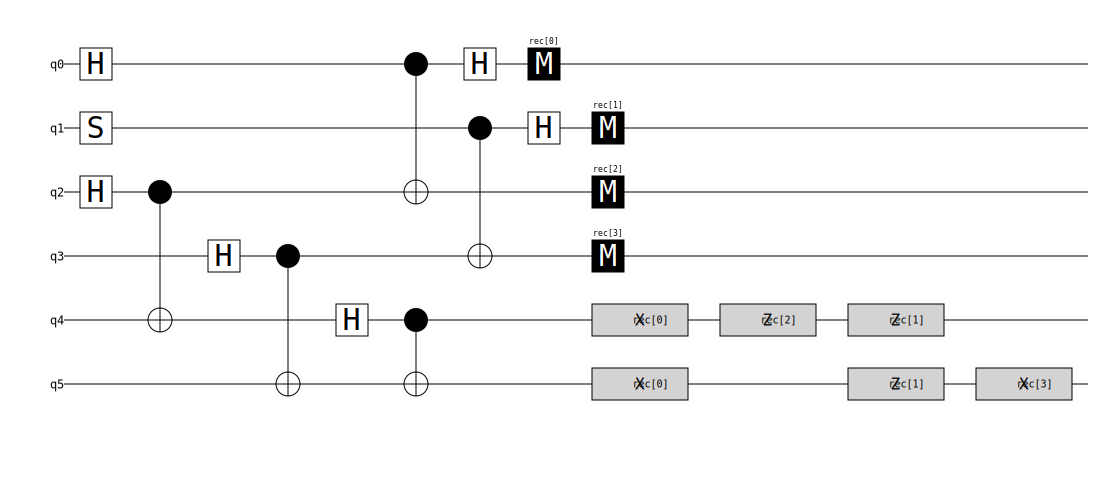

In [6]:
# The full protocol: resource preparation, C, teleportation measurements, and the
# feedforward correction on the output register (qubits 4, 5).
gate_teleport.diagram("timeline-svg")

### Verifying it works

As with state teleportation, we check the protocol against its definition: the output register should hold $C|\psi\rangle$. We prepare the input, run the full gate teleportation including the feedforward correction, then apply the inverse of "prepare $|\psi\rangle$, then apply $C$" to the output qubits. A correct protocol returns those qubits to $|0\rangle$ on every shot, and because the correction depends on the random measurement outcomes, passing across many shots exercises it for every outcome combination.

In [7]:
def test_gate_teleportation(shots=2000, seed=0):
    """
    Run gate teleportation, then undo it on the output register and measure. The output is
    C|psi>, so applying (prepare |psi>, then C)^dagger returns res_b to |00> on every shot
    whenever the feedforward correction is right -- for every measurement outcome.
    """
    c, data, res_a, res_b = build_gate_teleportation()

    # Rebuild "prepare |psi>, then apply C" on the output qubits res_b, and append its inverse.
    undo = stim.Circuit()
    undo.append("H", [res_b[0]]); undo.append("S", [res_b[1]])   # the input preparation
    small_clifford_on(undo, res_b[0], res_b[1])                  # C
    c += undo.inverse()

    c.append("M", res_b)                     # measure the two output qubits
    samples = c.compile_sampler(seed=seed).sample(shots)
    return int(samples[:, -2:].sum())        # last two columns are res_b; expect 0 everywhere

nonzero = test_gate_teleportation()
print(f"Shots where the output register was not |00> after teleport-and-undo: {nonzero}")
assert nonzero == 0, "Gate teleportation failed: the output register was not C|psi>."
print("Gate teleportation verified: the output register holds C|psi>.")

Shots where the output register was not |00> after teleport-and-undo: 0
Gate teleportation verified: the output register holds C|psi>.


## 3. From gate teleportation to CliNR

We can now state the central idea in one sentence.

**Clifford Noise Reduction is gate teleportation in which the resource state is first verified, by measuring a few of its stabilizers, and only accepted preparations are used.**

Everything from Section 2 carries over. The Clifford $C$ is built into a resource state, and teleportation moves it onto the data with a Pauli correction. CliNR adds a check between preparation and teleportation: measure a small set of the resource state's stabilizers. On a clean preparation these return the trivial outcome. If a fault occurred during preparation, it has some probability of flipping one of these stabilizer measurements, which signals that the preparation should be discarded and repeated.

### What a verification stabilizer is

A stabilizer of the resource state is a Pauli operator that leaves the state unchanged, so measuring it on a clean state gives the $+1$ outcome with certainty. The resource state has many such stabilizers; CliNR measures a chosen few of them. The choice matters, because different stabilizers detect different error patterns, and we return to this point in the demonstration.

### Why this placement of the check matters

The benefit comes from *where* the verification sits. The Clifford operation, which is the part of the circuit with the most two-qubit gates and therefore the most opportunities for faults, is prepared on the resource register, away from the data. The verification examines that register before the teleportation step connects it to the data. 

A faulty preparation is rejected before it can influence the computation. Only preparations that pass the check are teleported onto the data, and the teleportation step itself spreads a single fault no further than a single data qubit. 

The result is that the data is exposed only to errors that the verification was unable to catch, which are rarer and more localized than the errors a direct implementation would produce.

## 3-qubit CliNR demo

We now demonstrate the full CliNR protocol on a small 3-qubit example. This section simulates CliNR on this circuit, confirms it is correct with a noiseless check, and compares it against a direct implementation. 

### The Clifford 

We implement the three-qubit Clifford circuit 

$$C = H_1 \, \mathrm{CX}_{1,2} \, \mathrm{CZ}_{1,3},$$

a Hadamard on qubit 1, a CNOT from qubit 1 to qubit 2, and a controlled-Z between qubits 1 and 3. The circuit notation uses 1-based qubit indices; in code we index from 0, so this acts on qubits 0, 1, 2.

In [8]:
# Number of qubits the circuit C acts on.
N = 3

def C_on(circuit, qubits):
    """Append C = H CX CZ acting on the three given qubits, in the order (q0, q1, q2).
    Writing C as a function of its target qubits lets us place it on the data register
    or on a resource register without rewriting it."""
    q0, q1, q2 = qubits
    circuit.append('H',  [q0])        # Hadamard on the first qubit
    circuit.append('CX', [q0, q1])    # CNOT: control q0, target q1
    circuit.append('CZ', [q0, q2])    # controlled-Z between q0 and q2

# The tableau of C summarises how C transforms Pauli operators. We need it to compute
# the teleportation correction further down. Building it once here avoids recomputing it.
_c = stim.Circuit(); C_on(_c, [0, 1, 2])
C_TABLEAU = stim.Tableau.from_circuit(_c)

### The full CliNR protocol

CliNR for an `N`-qubit circuit uses `3N + 1` qubits, organised into three registers of `N` qubits plus one ancilla:

- **Block 1** holds the input state, the qubits we want to apply `C` to.
- **Block 2** and **Block 3** together hold `N` Bell pairs, one qubit of each pair in Block 2 and its partner in Block 3. The circuit `C` is applied to the Block 3 halves. This pair of registers is the resource state.
- **The ancilla** reads out the verification stabilizers, one at a time.

The steps, left to right in time, are:

1. Prepare the input state on Block 1 and the resource state on Blocks 2 and 3.
2. **Verify** the resource by measuring a short list of its stabilizers through the ancilla. On a clean resource these all return zero; a non-zero outcome signals a fault and the run is discarded (a restart).
3. **Teleport**: entangle Block 1 into Block 2 with CNOTs and Hadamards, then measure Blocks 1 and 2. This consumes the input and the resource, depositing `C` applied to the input on Block 3, up to a Pauli correction that depends on the measurement outcomes.
4. **Correct**: apply the outcome-dependent Pauli `Q` to Block 3. The corrected Block 3 is the output `C` applied to the input.

### The correction Q

The teleportation correction, in terms of the measurement outcomes, is

$$Q = \prod_{i=1}^{N} \left(C^{\dagger} X_{2N+i} C\right)^{o_{N+i}} \left(C^{\dagger} Z_{2N+i} C\right)^{o_{i}},$$

where $o_i$ is the measurement outcome of the Block 1 qubit $i$ and $o_{N+i}$ is the outcome of the Block 2 qubit $i$.

In [9]:
# Qubit layout for the 3N + 1 = 10 qubit CliNR circuit.
BLOCK1 = [0, 1, 2]   # input state            (paper qubits 1..3)
BLOCK2 = [3, 4, 5]   # Bell halves, measured  (paper qubits 4..6)
BLOCK3 = [6, 7, 8]   # Bell halves, hold C and the output (paper qubits 7..9)
ANC    = 9           # ancilla for stabilizer readout    (paper qubit 10)

In [10]:
def correction_paulis():
    """Return the per-qubit Pauli operators that make up the correction Q.

    For each output qubit i we need the operators that cancel an X byproduct and a Z
    byproduct. Following the discussion above, these are the forward-conjugated Paulis
    C X C^dag and C Z C^dag on Block 3, which Stim computes by applying the tableau of C.
    Returns two lists (x_corrections, z_corrections), one Pauli per output qubit."""
    full = stim.Tableau(3 * N)          # identity tableau on all 3N qubits
    full.append(C_TABLEAU, BLOCK3)      # embed C so it acts on the Block 3 qubits
    x_corr, z_corr = [], []
    for i in range(N):
        xi = stim.PauliString(3 * N); xi[BLOCK3[i]] = 1   # X on output qubit i
        zi = stim.PauliString(3 * N); zi[BLOCK3[i]] = 3   # Z on output qubit i
        x_corr.append(full(xi))         # C X C^dag, the X-byproduct correction
        z_corr.append(full(zi))         # C Z C^dag, the Z-byproduct correction
    return x_corr, z_corr

### Verification sequence

The verification sequence for this circuit uses two stabilizers of the resource state:

$$V_1 = X I I Z I I, \qquad V_2 = I Z I Z Z I,$$

written across the six resource qubits (Blocks 2 and 3). We use these two in the demonstration below. Each is a genuine stabilizer of the resource, so on a clean resource each measures to zero.

In [11]:
def paper_verification_sequence():
    """The two stabilizers V1 = XIIZII and V2 = IZIZZI of the resource state, as PauliStrings
    on the full 3N-qubit register. The paper writes them on the six resource qubits
    (1-based q1..q6); we map q1..q3 to Block 2 and q4..q6 to Block 3."""
    PQ = {1: BLOCK2[0], 2: BLOCK2[1], 3: BLOCK2[2],
          4: BLOCK3[0], 5: BLOCK3[1], 6: BLOCK3[2]}
    def pauli(spec):
        s = stim.PauliString(3 * N)
        for paper_qubit, letter in spec.items():
            s[PQ[paper_qubit]] = {'X': 1, 'Y': 2, 'Z': 3}[letter]
        return s
    V1 = pauli({1: 'X', 4: 'Z'})            # X I I Z I I
    V2 = pauli({2: 'Z', 4: 'Z', 5: 'Z'})    # I Z I Z Z I
    return [V1, V2]

In [12]:
def verify_gadget(circuit, stabilizer, ancilla):
    """Measure one stabilizer of the resource using a single ancilla.

    The ancilla is prepared in |+>, a controlled Pauli is applied for each non-identity
    factor of the stabilizer (control = ancilla, target = the data qubit), and the ancilla
    is read out in the X basis (H then measure). A zero outcome means the stabilizer was
    satisfied; a one means a fault was detected. The ancilla is reset for reuse."""
    circuit.append('R', [ancilla]); circuit.append('H', [ancilla])   # prepare |+>
    xs, zs = stabilizer.to_numpy()
    for q in range(3 * N):
        if   xs[q] and zs[q]: circuit.append('CY', [ancilla, q])   # Y factor
        elif xs[q]:           circuit.append('CX', [ancilla, q])   # X factor
        elif zs[q]:           circuit.append('CZ', [ancilla, q])   # Z factor
    circuit.append('H', [ancilla]); circuit.append('M', [ancilla]) # X-basis readout
    circuit.append('R', [ancilla])                                  # reset for next use

In [13]:
def build_clinr(stabilizers, prep_layers):
    """Construct the full dynamic CliNR circuit.

    prep_layers is a list of N gate lists describing how the input state is prepared on
    Block 1 (one gate list per qubit). stabilizers is the verification sequence.
    Returns (circuit, n_verifications)."""
    x_corr, z_corr = correction_paulis()
    c = stim.Circuit()

    # 1. Input state on Block 1.
    for q, layer in zip(BLOCK1, prep_layers):
        for g in layer: c.append(g, [q])

    # 2. Resource state: a Bell pair (Block 2 qubit, Block 3 qubit) for each i, then C
    #    on the Block 3 halves.
    for i in range(N):
        c.append('H',  [BLOCK2[i]])
        c.append('CX', [BLOCK2[i], BLOCK3[i]])
    C_on(c, BLOCK3)

    # 3. Verification. Each stabilizer is measured through the ancilla.
    n_ver = 0
    for stab in stabilizers:
        verify_gadget(c, stab, ANC)
        n_ver += 1

    # 4. Teleportation: entangle Block 1 into Block 2, then measure both blocks.
    for i in range(N):
        c.append('CX', [BLOCK1[i], BLOCK2[i]])
        c.append('H',  [BLOCK1[i]])
    c.append('M', BLOCK1)   # outcomes o_i      (drive the Z-byproduct correction)
    c.append('M', BLOCK2)   # outcomes o_{N+i}  (drive the X-byproduct correction)

    # 5. Correction Q on Block 3, applied in-circuit as classically controlled Paulis.
    #    Measurement record ordering: Block 1 was measured before Block 2, so its outcomes
    #    sit further back in the record. With N=3, Block1 outcomes are rec[-6]..-rec[-4]
    #    and Block2 outcomes are rec[-3]..-rec[-1]. The offsets -(2*N)+i and -(N)+i
    #    generalise this to arbitrary N.
    for i in range(N):
        for pauli, rec in ((z_corr[i], stim.target_rec(-(2 * N) + i)),
                           (x_corr[i], stim.target_rec(-(N) + i))):
            xs, zs = pauli.to_numpy()
            for q in range(3 * N):
                if   xs[q] and zs[q]: c.append('CY', [rec, q])
                elif xs[q]:           c.append('CX', [rec, q])
                elif zs[q]:           c.append('CZ', [rec, q])

    # 6. Measure the output on Block 3.
    c.append('M', BLOCK3)
    return c, n_ver

### The full toy circuit

Having assembled the pieces, we draw the complete three-qubit CliNR circuit. Every gate the protocol adds is visible here: the resource preparation and $C$, the two verification gadgets reading out through the ancilla, the teleportation, and the outcome-dependent correction. This is the overhead in full — and, at three qubits, it is exactly what keeps the protocol from paying off.

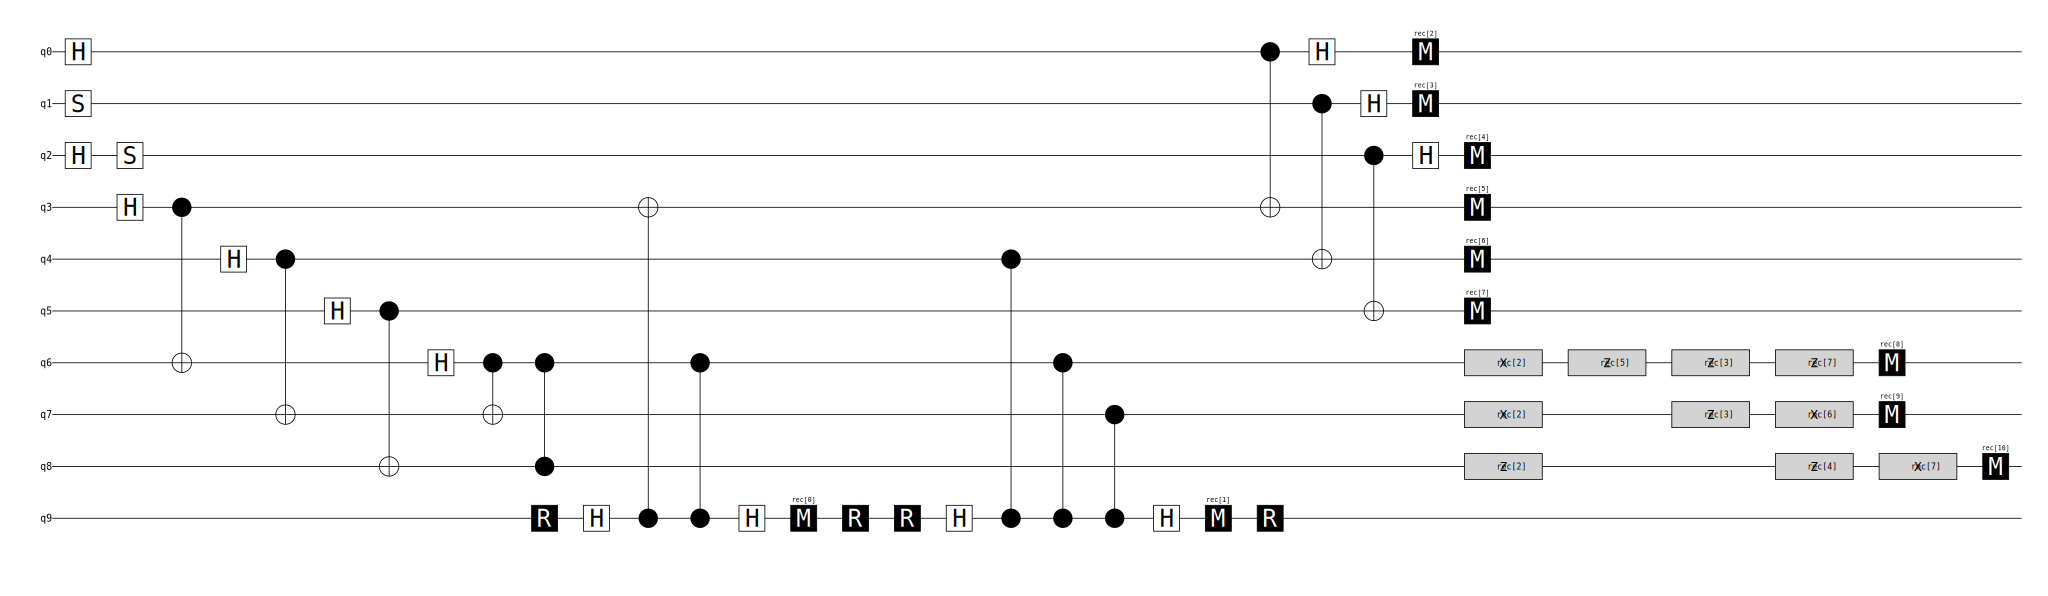

In [14]:
# Draw the complete toy circuit. build_clinr needs a verification sequence and an input
# preparation; we use the same ones the demonstration below uses (defined again here so this
# cell stands on its own). The diagram is wide -- that width is the point: it is the overhead.
demo_prep = [['H'], ['S'], ['H', 'S']]
demo_circuit, _ = build_clinr(paper_verification_sequence(), demo_prep)
demo_circuit.diagram("timeline-svg")

### The noise model

We use the standard circuit-level depolarizing model from the papers. A two-qubit gate is followed by two-qubit depolarizing noise at rate `p`; a single-qubit gate by single-qubit depolarizing noise at rate `p/10`; a measurement outcome is flipped with probability `p/10`. 

In [15]:
def add_noise(circuit, p):
    """Return a copy of circuit with depolarizing noise inserted after each operation.
    Two-qubit gates: rate p. Single-qubit gates: rate p/10. Measurements: outcome flipped
    with probability p/10. Resets and classically controlled gates are treated as noiseless,
    and idle noise is omitted. p = 0 returns the circuit unchanged."""
    if p == 0:
        return circuit.copy()                # no noise requested: hand back an untouched copy

    p1 = p / 10.0                            # single-qubit / measurement rate, ten times gentler
    one_qubit = {'H', 'S', 'S_DAG', 'X', 'Y', 'Z'}
    two_qubit = {'CX', 'CY', 'CZ', 'SWAP'}
    out = stim.Circuit()                     # we rebuild the circuit instruction by instruction

    for inst in circuit:
        name = inst.name
        targets = inst.targets_copy()
        # A classically controlled gate (feedforward) has a measurement-record target among its
        # operands. We detect that here so those gates can be left noiseless further down.
        is_feedforward = any(t.is_measurement_record_target for t in targets)
        # Qubit operands only, dropping any measurement-record target so pairing below is clean.
        qs = [t.value for t in targets if not t.is_measurement_record_target]

        if name in ('M', 'MZ'):
            # Model readout error by flipping the qubit just before it is measured, which is
            # equivalent to flipping the reported bit with probability p1.
            for q in qs: out.append('X_ERROR', [q], p1)
            out.append(inst)
        elif name == 'R' or is_feedforward:
            # Resets and feedforward corrections are taken as noiseless. This branch is checked
            # before the gate branches, so a feedforward CX/CY/CZ does not pick up two-qubit noise.
            out.append(inst)
        elif name in one_qubit:
            out.append(inst)
            for q in qs: out.append('DEPOLARIZE1', [q], p1)          # depolarize each acted-on qubit
        elif name in two_qubit:
            out.append(inst)
            # Two-qubit gate targets come in (control, target) pairs; noise-tag each pair.
            for k in range(0, len(qs), 2):
                out.append('DEPOLARIZE2', [qs[k], qs[k + 1]], p)
        else:
            out.append(inst)                 # anything else (e.g. H on the ancilla) passes through
    return out

## Measuring the output

To judge accuracy we compare the measured output distribution against the ideal one, the distribution of $C$ applied to the input with no noise. The distance we use is the total variation distance (TVD),

$$\mathrm{TVD}(P, Q) = \frac{1}{2} \sum_{x} \left| P(x) - Q(x) \right|,$$

half the sum of absolute differences between the two distributions $P$ and $Q$ over all outcomes $x$. It is zero for identical distributions and one for distributions with disjoint support.

For the CliNR circuit we keep only accepted shots (those where every verification measured zero) and form the output distribution from those. For the direct circuit there is no verification, so we use all shots.

In [16]:
def ideal_distribution(prep_layers):
    """Exact distribution of C applied to the input, with no noise.
    Computed from the state vector, which is feasible because N = 3 is small."""
    # Rebuild the input preparation followed by C on a clean N-qubit register.
    c = stim.Circuit()
    for q, layer in zip(range(N), prep_layers):
        for g in layer: c.append(g, [q])
    C_on(c, [0, 1, 2])

    # Evolve |0...0> through the circuit and read off the exact output probabilities.
    sim = stim.TableauSimulator(); sim.do_circuit(c)
    probs = np.abs(sim.state_vector()) ** 2
    # Stim's state vector is little-endian (qubit 0 is the least significant bit), while
    # measurement records list qubit 0 first, so we reverse the bit order to match.
    dist = {}
    for idx, pr in enumerate(probs):
        if pr > 1e-12:                                  # drop numerically-zero amplitudes
            bits = tuple(int(b) for b in format(idx, f'0{N}b')[::-1])
            dist[bits] = float(pr)
    return dist

def tvd(p, q):
    """Total variation distance between two distributions given as dicts."""
    keys = set(p) | set(q)                              # union of outcomes either one supports
    return 0.5 * sum(abs(p.get(k, 0) - q.get(k, 0)) for k in keys)

def clinr_output(stabilizers, prep_layers, p, shots, seed=0):
    """Run CliNR and return (accepted output distribution, acceptance rate)."""
    c, n_ver = build_clinr(stabilizers, prep_layers)
    samples = add_noise(c, p).compile_sampler(seed=seed).sample(shots)
    counts = {}; n_accept = 0
    for row in samples:
        # Each shot's measurement record is laid out in the order the circuit measured:
        # [n_ver verification bits][N Block1][N Block2][N Block3 output]. Walk it with a cursor.
        idx = 0
        verification = row[idx:idx + n_ver]; idx += n_ver
        idx += N            # skip Block 1 outcomes (consumed by the correction, not needed here)
        idx += N            # skip Block 2 outcomes (likewise)
        output = tuple(int(b) for b in row[idx:idx + N]); idx += N
        if any(int(b) for b in verification):   # any stabilizer flagged a fault: discard (restart)
            continue
        n_accept += 1
        counts[output] = counts.get(output, 0) + 1      # tally accepted outputs
    # Normalise the accepted counts into a distribution, and report the acceptance fraction.
    dist = {k: v / n_accept for k, v in counts.items()} if n_accept else {}
    return dist, (n_accept / shots if shots else 0.0)

def direct_output(prep_layers, p, shots, seed=0):
    """Run the direct implementation (just apply C and measure) and return its distribution."""
    # No teleportation, no verification: prepare the input, apply C, measure all N qubits.
    c = stim.Circuit()
    for q, layer in zip(range(N), prep_layers):
        for g in layer: c.append(g, [q])
    C_on(c, [0, 1, 2]); c.append('M', [0, 1, 2])
    samples = add_noise(c, p).compile_sampler(seed=seed).sample(shots)
    counts = {}
    for row in samples:
        k = tuple(int(b) for b in row[:N]); counts[k] = counts.get(k, 0) + 1   # tally every shot
    return {k: v / shots for k, v in counts.items()}

## Noiseless check

Before comparing error rates we confirm the protocol is correct. With no noise, accepted CliNR shots must reproduce the ideal output exactly.

In [17]:
# Input state for all comparisons: a fixed product of single-qubit Cliffords on Block 1.
# One inner list per qubit, giving the gates that prepare that qubit's part of |psi>.
PREP = [['H'], ['S'], ['H', 'S']]

# A high shot count makes the check insensitive to sampling fluctuations.
CHECK_SHOTS = 200_000

# The two resource-state stabilizers we verify against (defined earlier).
V = paper_verification_sequence()
print('Verification sequence:')
for stab in V:
    print('   ', stab)

# Exact target distribution, and the noiseless CliNR result to compare against it.
ideal = ideal_distribution(PREP)
dist0, accept0 = clinr_output(V, PREP, p=0.0, shots=CHECK_SHOTS)
# Outcomes CliNR produced that the ideal distribution cannot: a nonempty set signals a bug
# (most likely a wrongly-conjugated correction), since with no noise the two must agree.
off_support = set(dist0) - set(ideal)

print(f'\nNoiseless acceptance rate: {accept0:.3f}')
print(f'Outcomes outside the ideal support: {len(off_support)}')
print(f'TVD to ideal: {tvd(dist0, ideal):.5f}  (nonzero only from finite sampling)')

# With no noise: every accepted outcome must be ideal-supported, acceptance must be complete,
# and the residual TVD can only be sampling noise. Any failure here is a correctness bug.
assert len(off_support) == 0, 'Noiseless CliNR produced outcomes the ideal cannot: correction is wrong.'
assert accept0 > 0.999, 'Noiseless acceptance should be complete.'
assert tvd(dist0, ideal) < 0.01, 'Noiseless TVD is larger than sampling noise allows.'
print('\nNoiseless check passed: the implementation is correct.')

Verification sequence:
    +___X__Z__
    +____Z_ZZ_

Noiseless acceptance rate: 1.000
Outcomes outside the ideal support: 0
TVD to ideal: 0.00160  (nonzero only from finite sampling)

Noiseless check passed: the implementation is correct.


## Does CliNR help here?

Now we compare CliNR against the direct implementation across a range of two-qubit noise rates. For each rate we report the TVD of each method to the ideal output, and the CliNR acceptance rate. A lower TVD means a more accurate output. If CliNR helped, its TVD would sit below the direct TVD.

In [18]:
# Two-qubit noise rates to sweep. 1e-3 is the rate used in the larger demonstrations;
# the others bracket it to show the trend.
NOISE_RATES = [3e-4, 1e-3, 3e-3, 1e-2]
COMPARE_SHOTS = 100_000

# Collect, for each noise rate, the direct TVD, the CliNR TVD, and the CliNR acceptance rate.
direct_tvds, clinr_tvds, accepts = [], [], []
print(f'{"p (2-qubit)":>12} | {"direct TVD":>11} | {"CliNR TVD":>11} | {"CliNR accept":>12}')
print('-' * 56)
for p in NOISE_RATES:
    # Same seed for both methods at each rate, so the comparison is apples-to-apples.
    d_dist = direct_output(PREP, p, COMPARE_SHOTS, seed=1)
    c_dist, acc = clinr_output(V, PREP, p, COMPARE_SHOTS, seed=1)
    # Score each method by its distance to the exact (noiseless) output; lower is better.
    dt, ct = tvd(d_dist, ideal), tvd(c_dist, ideal)
    direct_tvds.append(dt); clinr_tvds.append(ct); accepts.append(acc)
    print(f'{p:>12.1e} | {dt:>11.4f} | {ct:>11.4f} | {acc:>12.3f}')

 p (2-qubit) |  direct TVD |   CliNR TVD | CliNR accept
--------------------------------------------------------
     3.0e-04 |      0.0019 |      0.0018 |        0.998
     1.0e-03 |      0.0025 |      0.0030 |        0.994
     3.0e-03 |      0.0053 |      0.0082 |        0.984
     1.0e-02 |      0.0172 |      0.0269 |        0.944


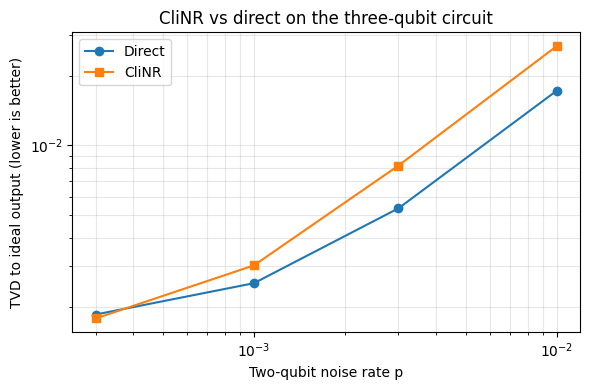

In [19]:
# Plot the two error curves against the noise rate.
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(NOISE_RATES, direct_tvds, 'o-', label='Direct')      # baseline: no protection
ax.plot(NOISE_RATES, clinr_tvds, 's-', label='CliNR')        # protected run (accepted shots only)
# Log-log axes: both the noise rate and the TVD span more than an order of magnitude.
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Two-qubit noise rate p')
ax.set_ylabel('TVD to ideal output (lower is better)')
ax.set_title('CliNR vs direct on the three-qubit circuit')
ax.legend(); ax.grid(True, which='both', alpha=0.3)          # grid on major and minor ticks
plt.tight_layout(); plt.show()

## What we see: When Does Verification Help?

Across the noise range, CliNR is at best tied with the direct implementation and otherwise worse. The verification does catch faults in the resource, but the price of catching them --- the gates that prepare the resource, run the two stabilizer measurements, and carry out the teleportation --- introduces more error than the verification removes. 

The benefit of CliNR grows with the size of the circuit being protected: a larger circuit accumulates more faults that verification can remove, while the verification and teleportation overhead grows more slowly.

The next notebook in this series demonstrates this on a ten-qubit circuit built from CZ gates, where the same protocol, specialised to CZ circuits as CZNR, reaches the regime where CliNR effectively helps in error mitigation. 

## References

[1] N. Delfosse and E. Tham, "Clifford Noise Reduction," arXiv:2407.06583 (2024).

[2] E. Tham and N. Delfosse, "Optimized Clifford Noise Reduction: Theory, Simulations and Experiments," *Quantum* **9**, 1829 (2025). [arXiv:2504.13356](https://arxiv.org/abs/2504.13356)